<a href="https://colab.research.google.com/github/ohadzr1/ADVLSI2_Project_updated/blob/main/ADVLSI2_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import os
import zipfile

In [ ]:
# Loading of Training dataset and data augmentation

# Unzip dataset
with zipfile.ZipFile('combined_training_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

class DRCDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['clean', 'dirty']
        self.file_list = []
        for idx, cls in enumerate(self.classes):
            path = os.path.join(self.root_dir, cls)
            for f in os.listdir(path):
                if f.endswith('.npy'):
                    self.file_list.append((os.path.join(path, f), idx))

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path, label = self.file_list[idx]
        matrix = np.load(file_path).astype(np.float32)
        matrix = torch.from_numpy(matrix).unsqueeze(0) # Channel dimension
        if self.transform:
            matrix = self.transform(matrix)
        return matrix, label

# Industry Standard Augmentation + Random Shift
data_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    # Translation of up to 10% (20px) to prevent spatial bias
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))
])

In [ ]:
# CNN Model defintion according to the article


class NCSU_DRCNN(nn.Module):
    def __init__(self):
        super(NCSU_DRCNN, self).__init__()
        # Conv1: 32 filters, 3x3
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) # 200 -> 100
        )
        # Conv2: 16 filters, 3x3
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) # 100 -> 50
        )
        # Conv3: 16 filters, 3x3
        self.conv3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) # 50 -> 25
        )
        # Conv4: 32 filters, 3x3
        self.conv4 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) # 25 -> 12
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 12 * 12, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Binary Classification
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
# Model Training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NCSU_DRCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.001)

# Loading and Splitting
dataset = DRCDataset(root_dir='data', transform=data_transforms)
train_size = int(0.80 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Total samples: {len(dataset)}")
print(f"Training: {len(train_data)} | Validation: {len(val_data)} | Testing: {len(test_data)}")


def train(epochs=20):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Simple Accuracy Check
        model.eval()
        correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                _, pred = torch.max(model(imgs), 1)
                correct += (pred == labels).sum().item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {100*correct/len(val_data):.2f}%")

train(epochs=20)

# Saving model
torch.save(model.state_dict(), 'ncsu_drcnn_weights.pth')
print("Training complete! Model saved to 'ncsu_drcnn_weights.pth'")

Total samples: 13065
Training: 10452 | Validation: 1959 | Testing: 654
Epoch 1/20 | Loss: 0.5207 | Val Acc: 75.45%
Epoch 2/20 | Loss: 0.2819 | Val Acc: 92.24%
Epoch 3/20 | Loss: 0.1833 | Val Acc: 93.77%
Epoch 4/20 | Loss: 0.1371 | Val Acc: 95.66%
Epoch 5/20 | Loss: 0.1013 | Val Acc: 96.58%
Epoch 6/20 | Loss: 0.0818 | Val Acc: 97.35%
Epoch 7/20 | Loss: 0.0730 | Val Acc: 96.89%
Epoch 8/20 | Loss: 0.0669 | Val Acc: 96.17%
Epoch 9/20 | Loss: 0.0623 | Val Acc: 97.65%
Epoch 10/20 | Loss: 0.0605 | Val Acc: 97.86%
Epoch 11/20 | Loss: 0.0604 | Val Acc: 97.29%
Epoch 12/20 | Loss: 0.0549 | Val Acc: 98.42%
Epoch 13/20 | Loss: 0.0549 | Val Acc: 97.65%
Epoch 14/20 | Loss: 0.0501 | Val Acc: 98.42%
Epoch 15/20 | Loss: 0.0511 | Val Acc: 98.83%
Epoch 16/20 | Loss: 0.0493 | Val Acc: 98.52%
Epoch 17/20 | Loss: 0.0486 | Val Acc: 98.11%
Epoch 18/20 | Loss: 0.0436 | Val Acc: 98.42%
Epoch 19/20 | Loss: 0.0468 | Val Acc: 98.72%
Epoch 20/20 | Loss: 0.0451 | Val Acc: 98.26%
Training complete! Model saved to 'ncs

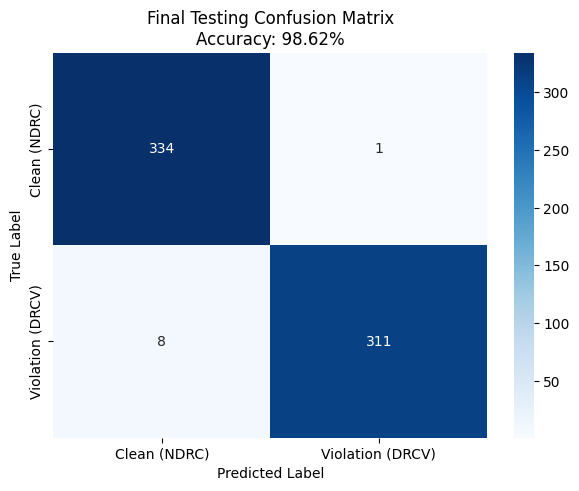


Final Performance Report:
              precision    recall  f1-score   support

       Clean       0.98      1.00      0.99       335
   Violation       1.00      0.97      0.99       319

    accuracy                           0.99       654
   macro avg       0.99      0.99      0.99       654
weighted avg       0.99      0.99      0.99       654



In [ ]:
# Geenration of confusion matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Switch to evaluation mode
model.eval()
all_preds = []
all_labels = []

# Final inference on the Testing Set (the 5%)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Final Accuracy
cm = confusion_matrix(all_labels, all_preds)
accuracy = (cm[0,0] + cm[1,1]) / sum(sum(cm))

# Visualization of the Confusion Matrix (similar to Figure 7 in paper)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean (NDRC)', 'Violation (DRCV)'],
            yticklabels=['Clean (NDRC)', 'Violation (DRCV)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Final Testing Confusion Matrix\nAccuracy: {accuracy*100:.2f}%')
plt.show()

# Print full report (Recall and Precision)
print("\nFinal Performance Report:")
print(classification_report(all_labels, all_preds, target_names=['Clean', 'Violation']))

In [ ]:

# Inference - model excecution on inference dataset

import os
import numpy as np
import torch
import time
import zipfile
import io

# --- CONFIGURATION ---
# Point directly to the ZIP file shown in your Colab root directory
ZIP_PATH ="/content/inference_dataset.zip"
CONFIDENCE_THRESHOLD = 0.80

def scan_layout_from_zip(model, zip_file_path, threshold=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    if not os.path.exists(zip_file_path):
        print(f"[!] Error: Could not find ZIP file at {zip_file_path}")
        return

    print(f"[*] Opening ZIP archive at {zip_file_path}...")

    violations = []
    start_time = time.time()

    # Open the ZIP file directly
    with zipfile.ZipFile(zip_file_path, 'r') as archive:
        # Filter only .npy files from the archive list
        npy_files = [f for f in archive.namelist() if f.endswith('.npy')]

        if not npy_files:
            print("[!] Error: No .npy files found inside the ZIP.")
            return

        print(f"[*] Starting DRC scan on {len(npy_files)} tiles directly from ZIP using {device}...")

        with torch.no_grad():
            for i, filename in enumerate(npy_files):
                # Read the raw bytes from the ZIP into memory
                with archive.open(filename) as f:
                    file_bytes = f.read()
                    # Convert bytes directly to a NumPy array
                    matrix = np.load(io.BytesIO(file_bytes)).astype(np.float32)

                # Format for CNN: (1, 1, 200, 200)
                tensor = torch.from_numpy(matrix).unsqueeze(0).unsqueeze(0).to(device)

                outputs = model(tensor)
                probs = torch.softmax(outputs, dim=1)
                violation_prob = probs[0][1].item()

                if violation_prob >= threshold:
                    # Extract pure filename without folder paths that might be in the ZIP
                    base_name = os.path.basename(filename)
                    coords = base_name.replace("tile_", "").replace(".npy", "")
                    violations.append((coords, violation_prob))

                if (i + 1) % 2000 == 0:
                    print(f"[>] Scanned {i + 1}/{len(npy_files)} tiles...")

    end_time = time.time()
    print(f"\n[+] Scan complete in {end_time - start_time:.1f} seconds!")

    # --- Print results and save report ---
    print("=" * 40)
    if not violations:
        print("[*] LAYOUT IS CLEAN! No DRC violations found.")
    else:
        print(f"[!] FOUND {len(violations)} POTENTIAL VIOLATIONS!")
        print("=" * 40)

        with open("drc_report.txt", "w") as f:
            f.write("CNN DRC Violations Report\n")
            f.write("=========================\n")
            for coords, prob in violations:
                line = f"Location: {coords} | Confidence: {prob:.2%}"
                print(f"  - {line}")
                f.write(line + "\n")

        print("\n[-] Detailed report saved to 'drc_report.txt' in Colab files.")

# --- 1. Model Initialization ---
model = NCSU_DRCNN()

# --- 2. Load Trained Weights ---
model_weights_path = 'ncsu_drcnn_weights.pth'

model.load_state_dict(torch.load(model_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'), weights_only=True))

# --- 3. Execute Inference ---
scan_layout_from_zip(model, ZIP_PATH, CONFIDENCE_THRESHOLD)


[*] Opening ZIP archive at /content/inference_dataset.zip...
[*] Starting DRC scan on 10471 tiles directly from ZIP using cuda...
[>] Scanned 2000/10471 tiles...
[>] Scanned 4000/10471 tiles...
[>] Scanned 6000/10471 tiles...
[>] Scanned 8000/10471 tiles...
[>] Scanned 10000/10471 tiles...

[+] Scan complete in 12.2 seconds!
[!] FOUND 4 POTENTIAL VIOLATIONS!
  - Location: x65500_y130500 | Confidence: 100.00%
  - Location: x65500_y132000 | Confidence: 100.00%
  - Location: x65500_y133500 | Confidence: 100.00%
  - Location: x65500_y135000 | Confidence: 100.00%

[-] Detailed report saved to 'drc_report.txt' in Colab files.


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to extract activations and gradients during forward/backward passes
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.eval()

        # Forward pass to get the model's predictions
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        # Backward pass to calculate gradients for the target class
        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        # Retrieve the computed gradients and activations
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]

        # Calculate the channel weights based on the mean of the gradients
        weights = np.mean(gradients, axis=(1, 2))

        # Generate the heatmap by computing the weighted sum of the activations
        heatmap = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            heatmap += w * activations[i]

        # Apply ReLU to keep only features that have a positive influence on the class, and normalize
        heatmap = np.maximum(heatmap, 0)
        heatmap = cv2.resize(heatmap, (input_tensor.shape[3], input_tensor.shape[2]))
        heatmap = heatmap - np.min(heatmap)
        heatmap = heatmap / np.max(heatmap)
        return heatmap

def show_gradcam_on_layout(npy_path, model, class_idx=1): # class_idx=1 represents the "dirty/violation" class
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Load the layout numpy array
    matrix = np.load(npy_path).astype(np.float32)
    input_tensor = torch.from_numpy(matrix).unsqueeze(0).unsqueeze(0).to(device)
    input_tensor.requires_grad = True # Required to compute gradients for Grad-CAM

    # Initialize GradCAM pointing to the deepest convolutional layer (conv4)
    grad_cam = GradCAM(model, model.conv4)

    # Generate the heatmap for the specified violation class
    heatmap = grad_cam.generate_heatmap(input_tensor, class_idx=class_idx)

    # Prepare the original layout image for display (normalization)
    img_display = matrix
    img_display = (img_display - np.min(img_display)) / (np.max(img_display) - np.min(img_display))
    img_display = np.uint8(255 * img_display)

    # Invert colors: Ensure metal polygons and background match the expected visual representation
    img_display = 255 - img_display

    # Convert the heatmap to RGB format (Red indicates "hot" areas with high influence)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Superimpose the heatmap onto the original layout image
    # Weights (0.5 and 0.5) are balanced to keep the underlying layout geometry visible
    superimposed_img = heatmap_colored * 0.5 + cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB) * 0.5
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Plotting the three stages: Original, Heatmap, and Superimposed result
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original Layout")
    plt.imshow(img_display, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(heatmap, cmap='jet')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Superimposed (Violation Area)")
    plt.imshow(superimposed_img)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Make sure to run this after your model is loaded/trained
# sample_dirty_layout = 'data/dirty/tile_example_123.npy'
# show_gradcam_on_layout(sample_dirty_layout, model, class_idx=1)

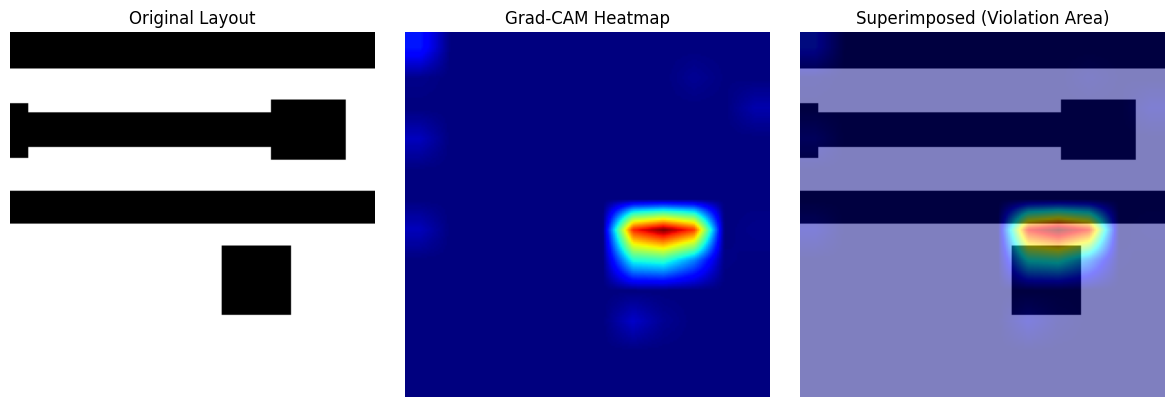

In [ ]:
# Make sure your model is loaded with the trained weights
model = NCSU_DRCNN()
model.load_state_dict(torch.load('ncsu_drcnn_weights.pth', map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

# Point to a specific tile you know has a violation
sample_dirty_layout = 'data/dirty/tt_um_8_bit_cpu_tile_74360_60880.npy'

# Run the visualization!
show_gradcam_on_layout(sample_dirty_layout, model, class_idx=1)